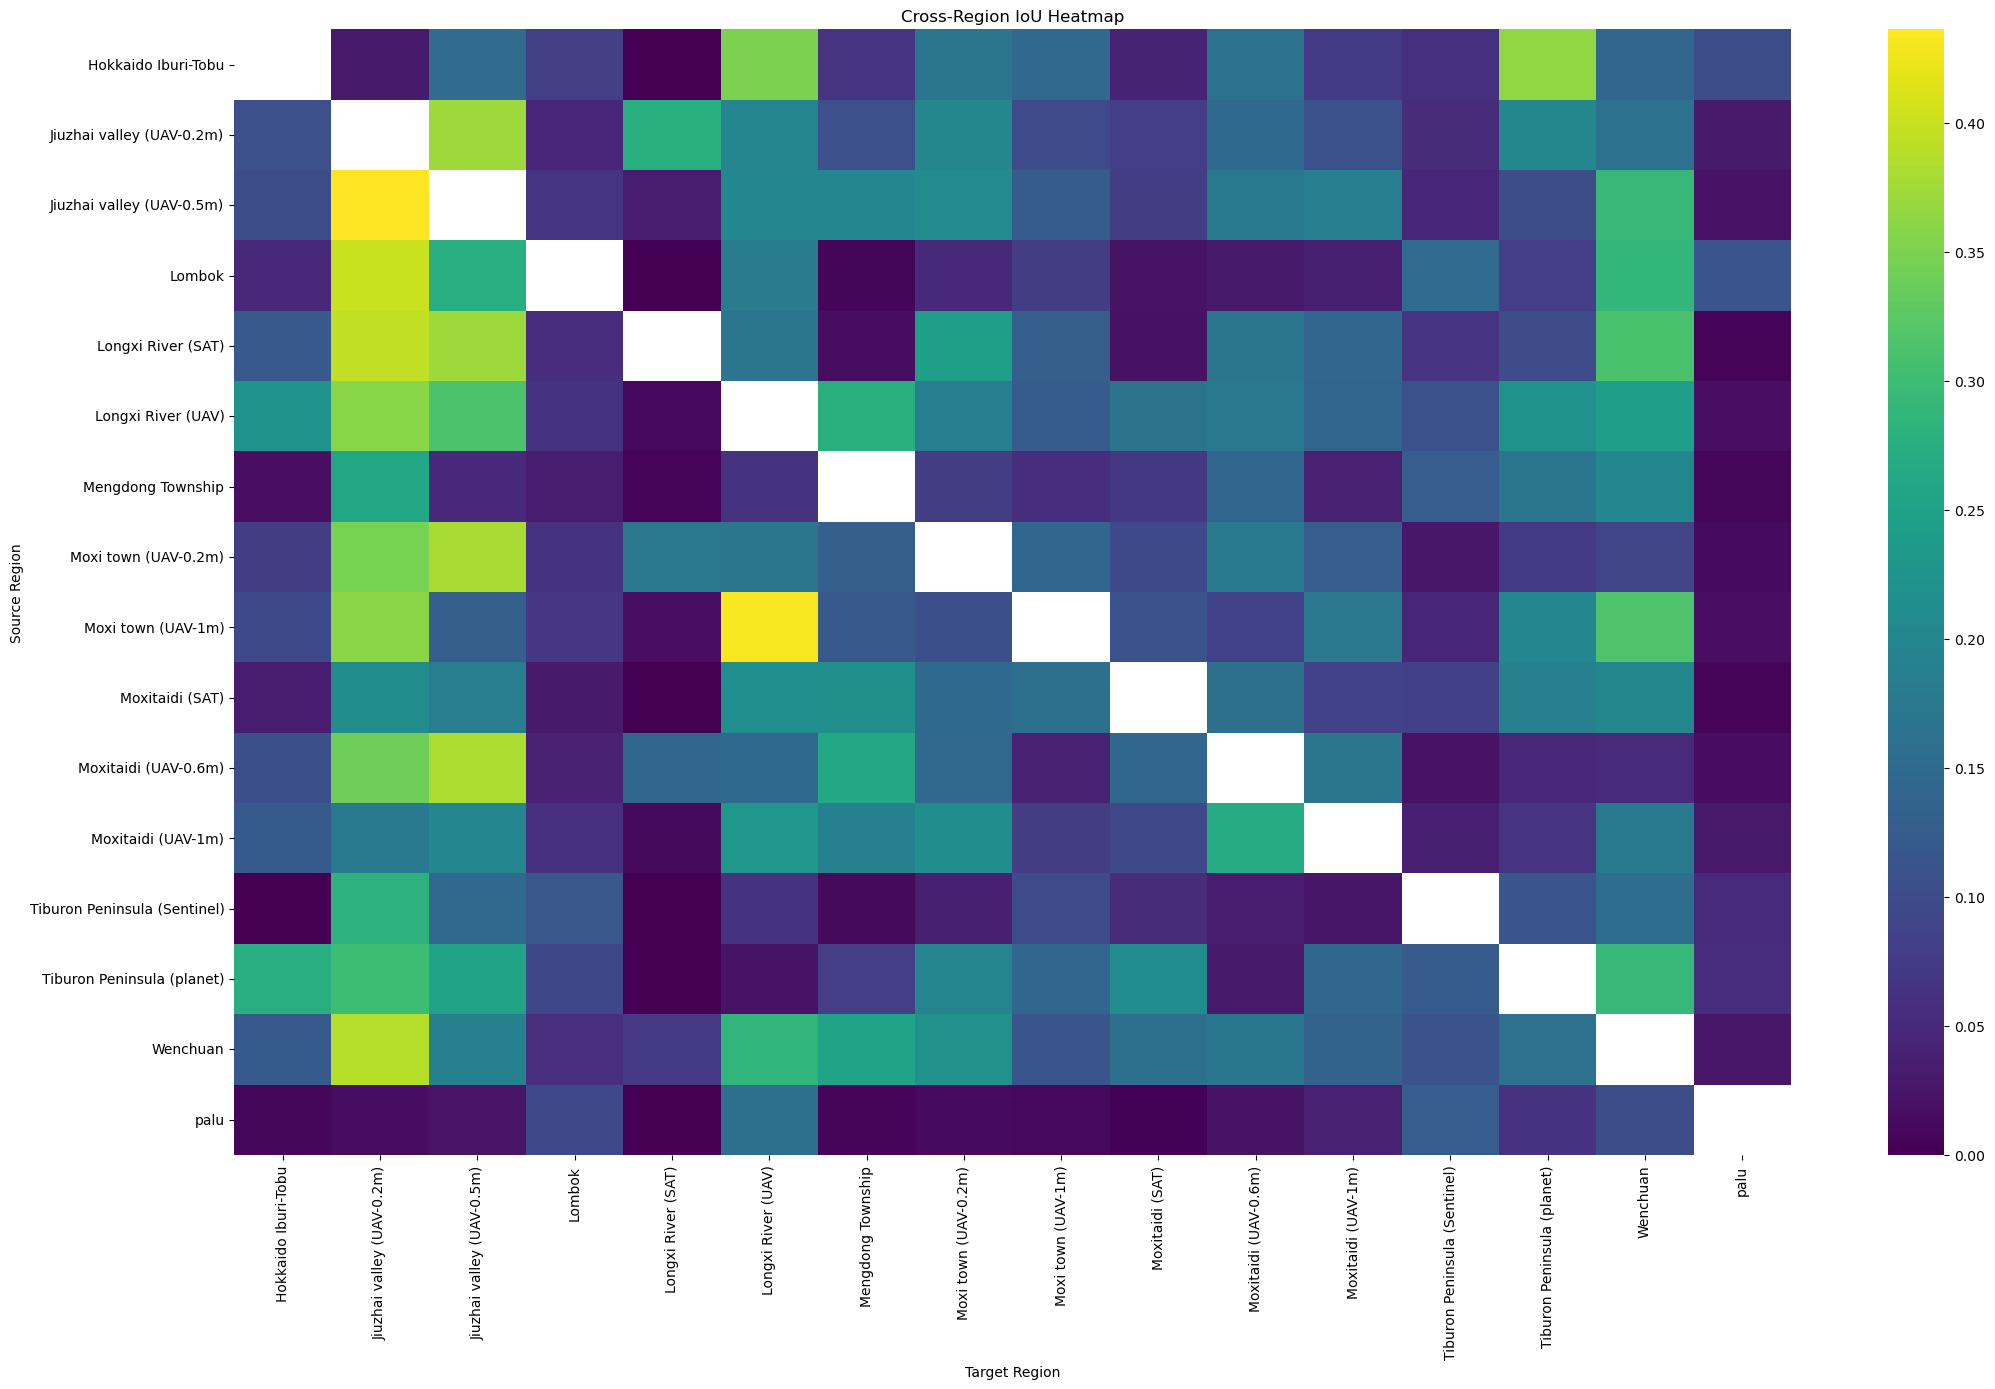

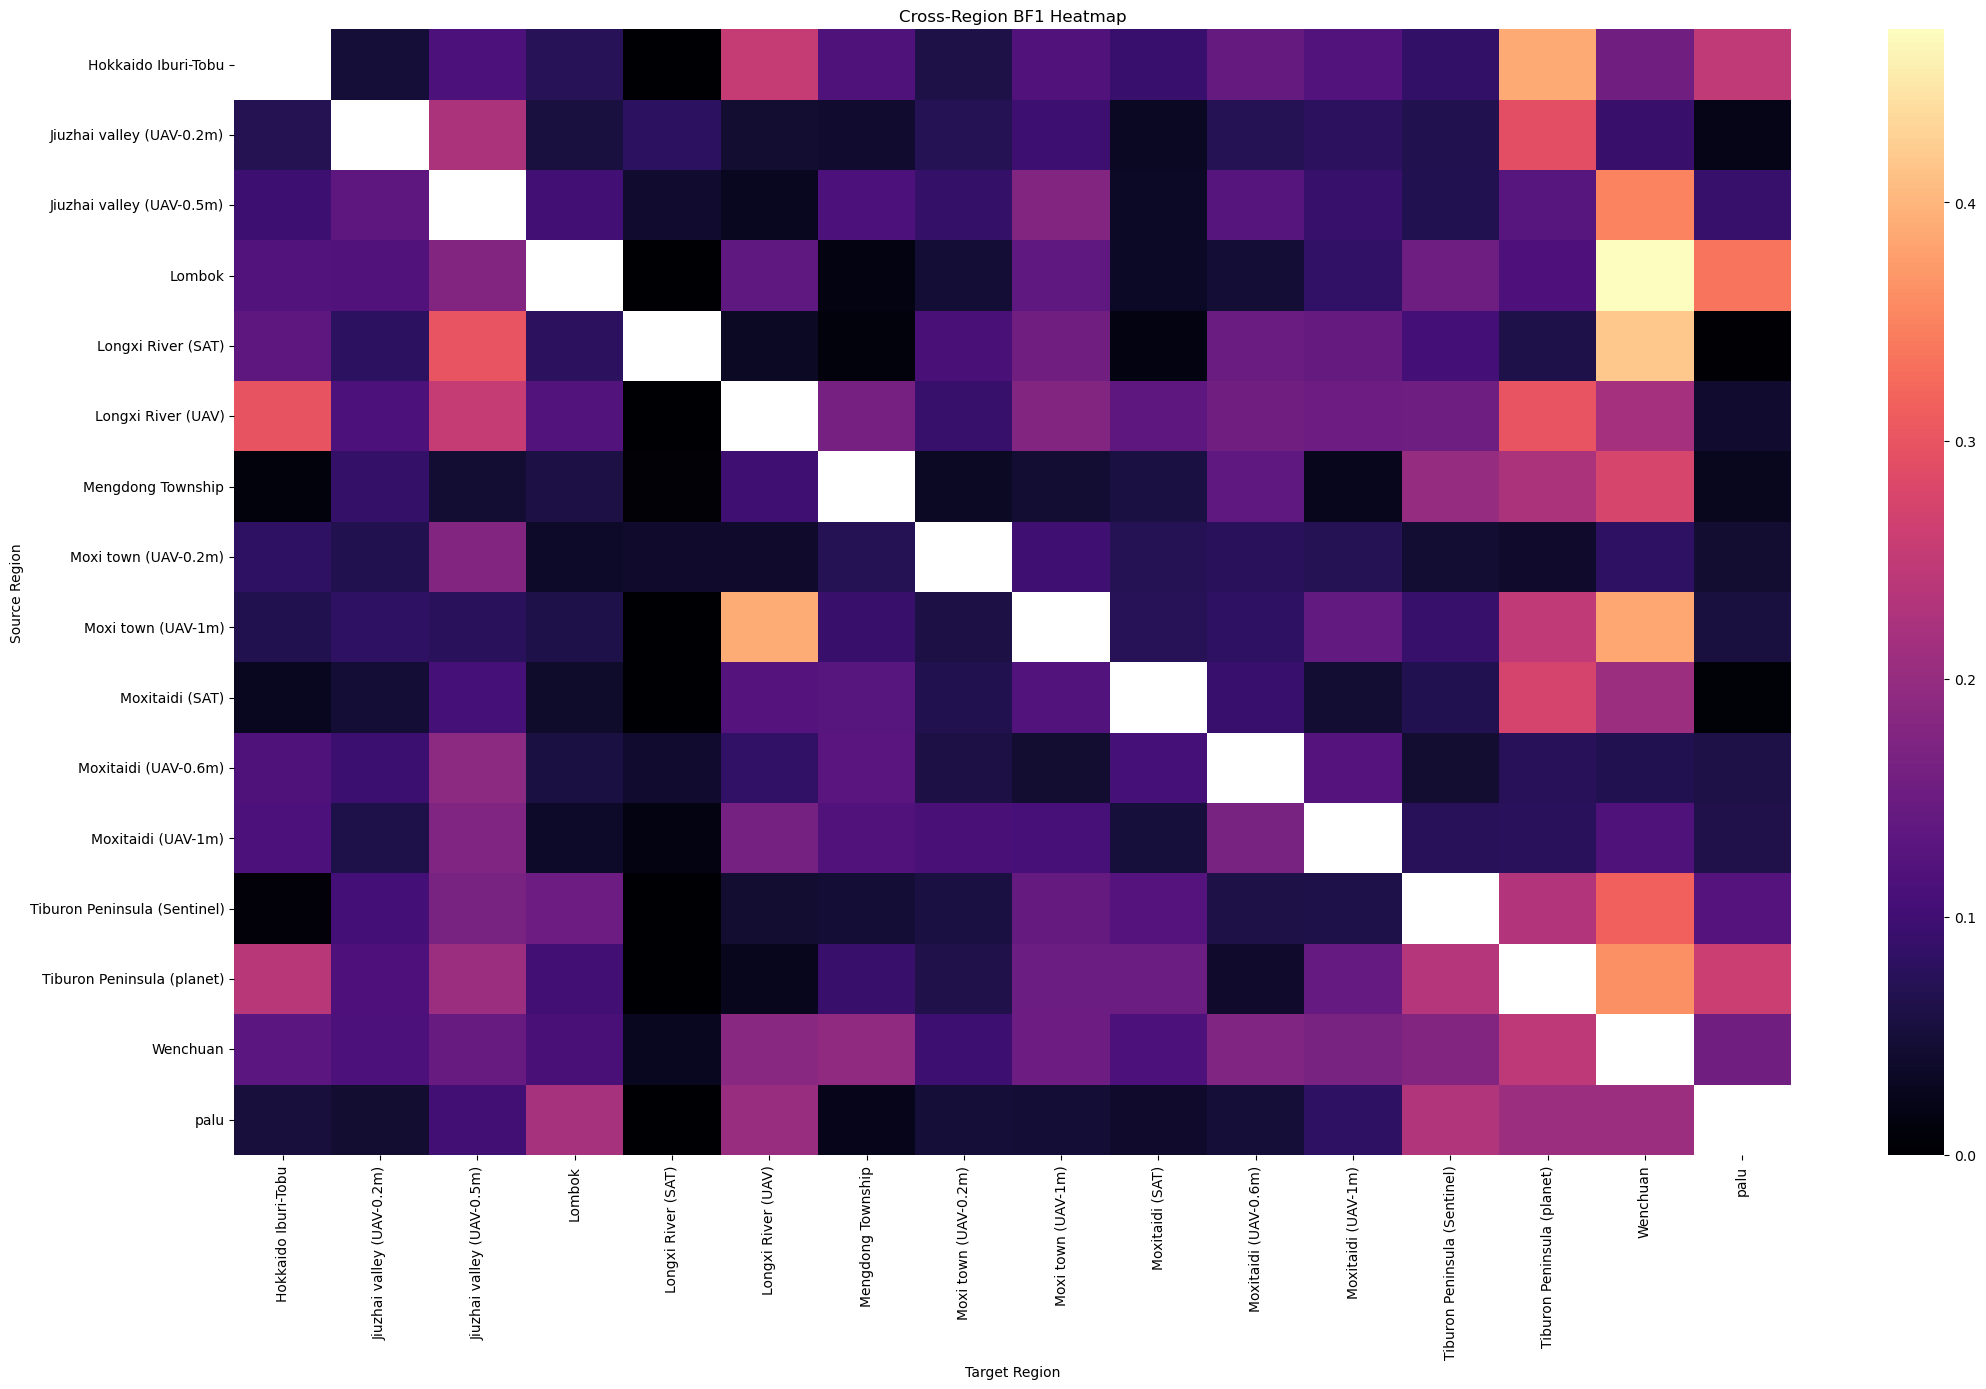

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../results/spn/test1.csv")

df["source_region"] = df["source_region"].str.strip()
df["target_region"] = df["target_region"].str.strip()

pivot_iou = df.pivot_table(
    index="source_region",
    columns="target_region",
    values="iou"
)

plt.figure(figsize=(22, 14))
sns.heatmap(pivot_iou, annot=False, cmap="viridis")
plt.title("Cross-Region IoU Heatmap")
plt.xlabel("Target Region")
plt.ylabel("Source Region")
plt.tight_layout()
plt.show()

pivot_bf1 = df.pivot_table(
    index="source_region",
    columns="target_region",
    values="bf1"
)

plt.figure(figsize=(22, 14))
sns.heatmap(pivot_bf1, annot=False, cmap="magma")
plt.title("Cross-Region BF1 Heatmap")
plt.xlabel("Target Region")
plt.ylabel("Source Region")
plt.tight_layout()
plt.show()

def plot_iou_for_source(source):
    sub = df[df["source_region"] == source]
    plt.figure(figsize=(18, 6))
    sns.barplot(data=sub, x="target_region", y="iou")
    plt.xticks(rotation=90)
    plt.title(f"IoU across all targets (source = {source})")
    plt.tight_layout()
    plt.show()

def plot_bf1_for_source(source):
    sub = df[df["source_region"] == source]
    plt.figure(figsize=(18, 6))
    sns.barplot(data=sub, x="target_region", y="bf1")
    plt.xticks(rotation=90)
    plt.title(f"BF1 across all targets (source = {source})")
    plt.tight_layout()
    plt.show()

def plot_iou_for_target(target):
    sub = df[df["target_region"] == target]
    plt.figure(figsize=(18, 6))
    sns.barplot(data=sub, x="source_region", y="iou")
    plt.xticks(rotation=90)
    plt.title(f"IoU across all sources (target = {target})")
    plt.tight_layout()
    plt.show()

def plot_bf1_for_target(target):
    sub = df[df["target_region"] == target]
    plt.figure(figsize=(18, 6))
    sns.barplot(data=sub, x="source_region", y="bf1")
    plt.xticks(rotation=90)
    plt.title(f"BF1 across all sources (target = {target})")
    plt.tight_layout()
    plt.show()

In [5]:
import pandas as pd
import glob
import os

def load_all_spectral_summaries(folder="../../results/old/spectral/"):
    rows = []
    for csv in glob.glob(os.path.join(folder, "*.csv")):
        region = os.path.basename(csv).replace(".csv","")
        df = pd.read_csv(csv)
        rows.append({
            "region": region,
            "mean_centroid": df["centroid"].mean(),
            "mean_lf_hf": df["lf_hf"].mean(),
            "n_images": len(df)
        })
    return pd.DataFrame(rows)

spectral_df = load_all_spectral_summaries()
print(spectral_df)


              region  mean_centroid  mean_lf_hf  n_images
0           hokkaido     135.191831    0.499616       100
1            jiuzhai     121.361369    0.786610       100
2         jiuzhai_02      89.375327    1.505914       100
3         jiuzhai_05     121.361369    0.786610       100
4             lombok     126.221242    0.643847       100
5             longxi     139.066686    0.581193       100
6         longxi_sat      57.040449    3.975609       100
7           mengdong      87.768854    1.458415       100
8       moxitaidi_06     101.661969    1.165326       100
9        moxitaidi_1     119.803983    0.789367       100
10     moxitaidi_sat     115.727501    0.820578       100
11           moxi_02     150.496672    0.441951       100
12            moxi_1     156.563518    0.407112       100
13              palu     132.463386    0.546262       100
14    tiburon_planet      63.925133    3.221951       100
15  tiburon_sentinel     119.586676    0.742751       100
16          we

In [7]:
import pandas as pd

results = pd.read_csv("../../results/spn/test1.csv")
results["source_region"] = results["source_region"].str.strip()
results["target_region"] = results["target_region"].str.strip()

print(results.head())

         source_region              target_region  precision  recall      f1  \
0  Hokkaido Iburi-Tobu  Jiuzhai valley (UAV-0.2m)     0.7464  0.0295  0.0567   
1  Hokkaido Iburi-Tobu  Jiuzhai valley (UAV-0.5m)     0.2273  0.3193  0.2656   
2  Hokkaido Iburi-Tobu                     Lombok     0.1262  0.1836  0.1496   
3  Hokkaido Iburi-Tobu         Longxi River (SAT)     0.0000  0.0000  0.0000   
4  Hokkaido Iburi-Tobu         Longxi River (UAV)     0.5609  0.4825  0.5188   

      iou    miou      oa     bf1  
0  0.0292  0.3941  0.7607  0.0498  
1  0.1531  0.4715  0.7975  0.1138  
2  0.0809  0.5085  0.9364  0.0722  
3  0.0000  0.4499  0.8998  0.0005  
4  0.3502  0.5944  0.8514  0.2534  


In [ ]:
region_map = {
    "Hokkaido Iburi-Tobu": "hokkaido",

    "Jiuzhai valley (UAV-0.2m)": "jiuzhai_02",
    "Jiuzhai valley (UAV-0.5m)": "jiuzhai_05",

    "Lombok": "lombok",

    "Longxi River (SAT)": "longxi_sat",
    "Longxi River (UAV)": "longxi",

    "Mengdong Township": "mengdong",

    "Moxi town (UAV-0.2m)": "moxi_02",
    "Moxi town (UAV-1m)": "moxi_1",

    "Moxitaidi (SAT)": "moxitaidi_sat",
    "Moxitaidi (UAV-0.6m)": "moxitaidi_06",
    "Moxitaidi (UAV-1m)": "moxitaidi_1",

    "palu": "palu",

    "Tiburon Peninsula (planet)": "tiburon_planet",
    "Tiburon Peninsula (Sentinel)": "tiburon_sentinel",

    "Wenchuan": "wenchuan",
}

results["source_region"] = results["source_region"].map(region_map)
results["target_region"] = results["target_region"].map(region_map)


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

merged = results.merge(
    spectral_df.rename(columns={
        "region": "source_region",
        "mean_centroid": "source_centroid",
        "mean_lf_hf": "source_lf_hf"
    }),
    on="source_region",
    how="left"
).merge(
    spectral_df.rename(columns={
        "region": "target_region",
        "mean_centroid": "target_centroid",
        "mean_lf_hf": "target_lf_hf"
    }),
    on="target_region",
    how="left"
)

merged["centroid_diff"] = np.abs(merged["source_centroid"] - merged["target_centroid"])
merged["lfhf_diff"] = np.abs(merged["source_lf_hf"] - merged["target_lf_hf"])

print(merged.head())


  source_region target_region  precision  recall      f1     iou    miou  \
0      hokkaido    jiuzhai_02     0.7464  0.0295  0.0567  0.0292  0.3941   
1      hokkaido    jiuzhai_05     0.2273  0.3193  0.2656  0.1531  0.4715   
2      hokkaido        lombok     0.1262  0.1836  0.1496  0.0809  0.5085   
3      hokkaido    longxi_sat     0.0000  0.0000  0.0000  0.0000  0.4499   
4      hokkaido        longxi     0.5609  0.4825  0.5188  0.3502  0.5944   

       oa     bf1  source_centroid  source_lf_hf  n_images_x  target_centroid  \
0  0.7607  0.0498       135.191831      0.499616         100        89.375327   
1  0.7975  0.1138       135.191831      0.499616         100       121.361369   
2  0.9364  0.0722       135.191831      0.499616         100       126.221242   
3  0.8998  0.0005       135.191831      0.499616         100        57.040449   
4  0.8514  0.2534       135.191831      0.499616         100       139.066686   

   target_lf_hf  n_images_y  centroid_diff  lfhf_diff  


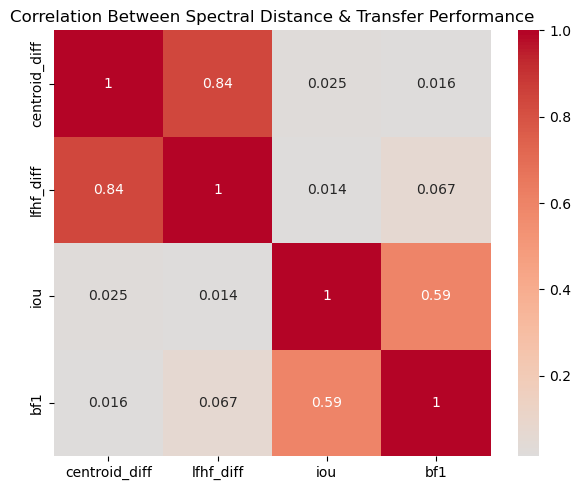

In [14]:
corr = merged[["centroid_diff", "lfhf_diff", "iou", "bf1"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Between Spectral Distance & Transfer Performance")
plt.tight_layout()
plt.show()


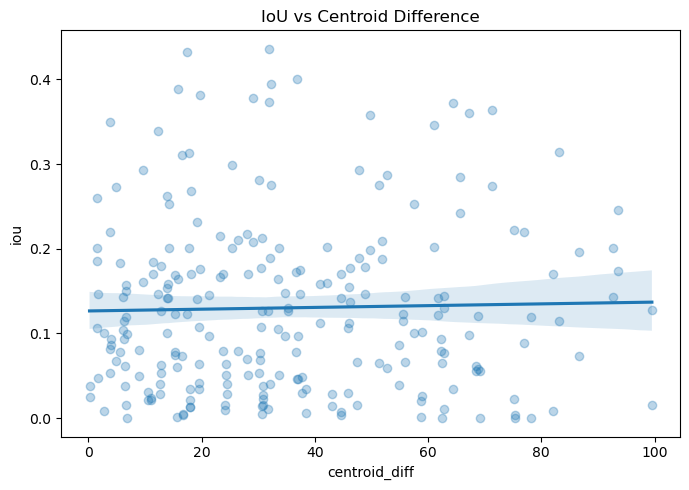

In [15]:
plt.figure(figsize=(7,5))
sns.regplot(data=merged, x="centroid_diff", y="iou", scatter_kws={"alpha":0.3})
plt.title("IoU vs Centroid Difference")
plt.tight_layout()
plt.show()


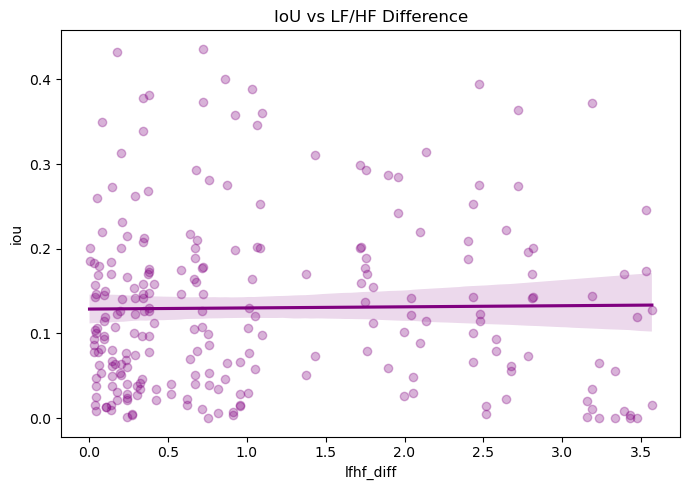

In [16]:
plt.figure(figsize=(7,5))
sns.regplot(data=merged, x="lfhf_diff", y="iou", scatter_kws={"alpha":0.3}, color="purple")
plt.title("IoU vs LF/HF Difference")
plt.tight_layout()
plt.show()


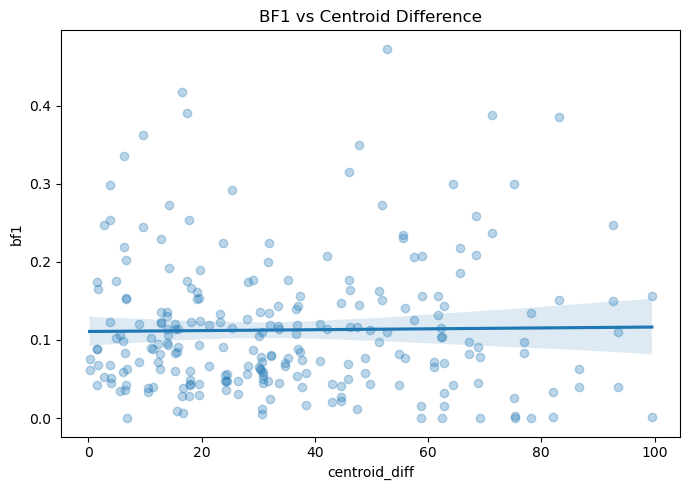

In [17]:
plt.figure(figsize=(7,5))
sns.regplot(data=merged, x="centroid_diff", y="bf1", scatter_kws={"alpha":0.3})
plt.title("BF1 vs Centroid Difference")
plt.tight_layout()
plt.show()


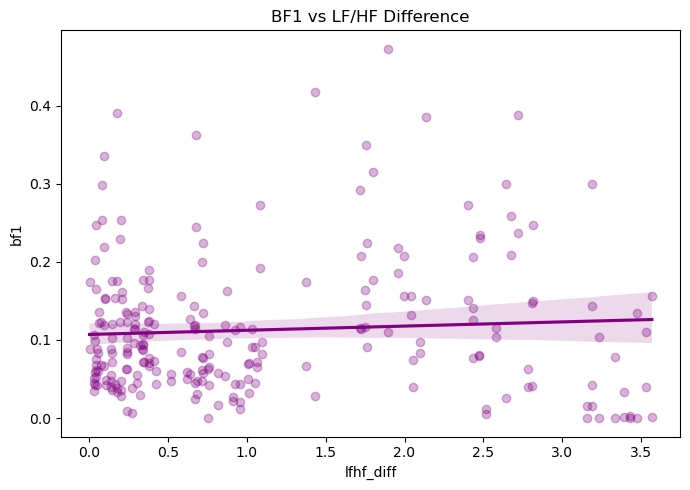

In [18]:
plt.figure(figsize=(7,5))
sns.regplot(data=merged, x="lfhf_diff", y="bf1", scatter_kws={"alpha":0.3}, color="purple")
plt.title("BF1 vs LF/HF Difference")
plt.tight_layout()
plt.show()


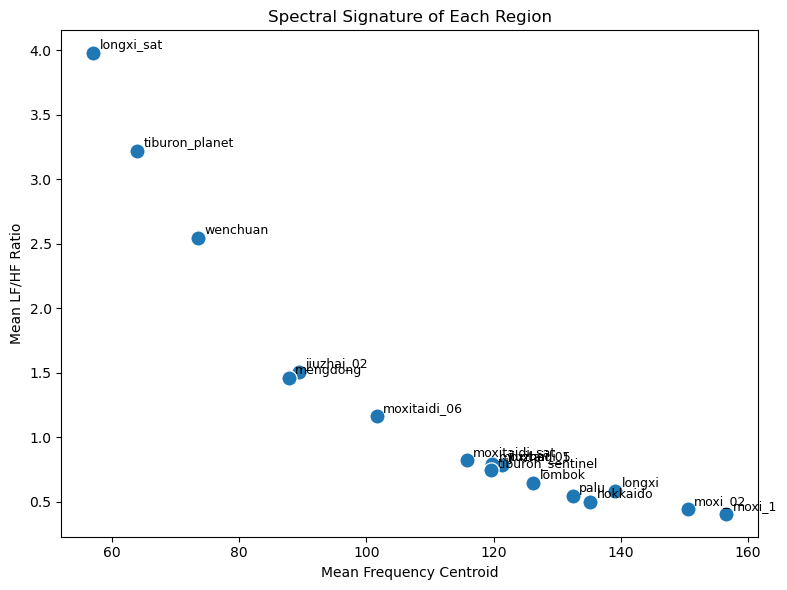

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=spectral_df, x="mean_centroid", y="mean_lf_hf", s=120)

for _, row in spectral_df.iterrows():
    plt.text(row.mean_centroid + 1, row.mean_lf_hf + 0.03, row.region, fontsize=9)

plt.title("Spectral Signature of Each Region")
plt.xlabel("Mean Frequency Centroid")
plt.ylabel("Mean LF/HF Ratio")
plt.tight_layout()
plt.show()


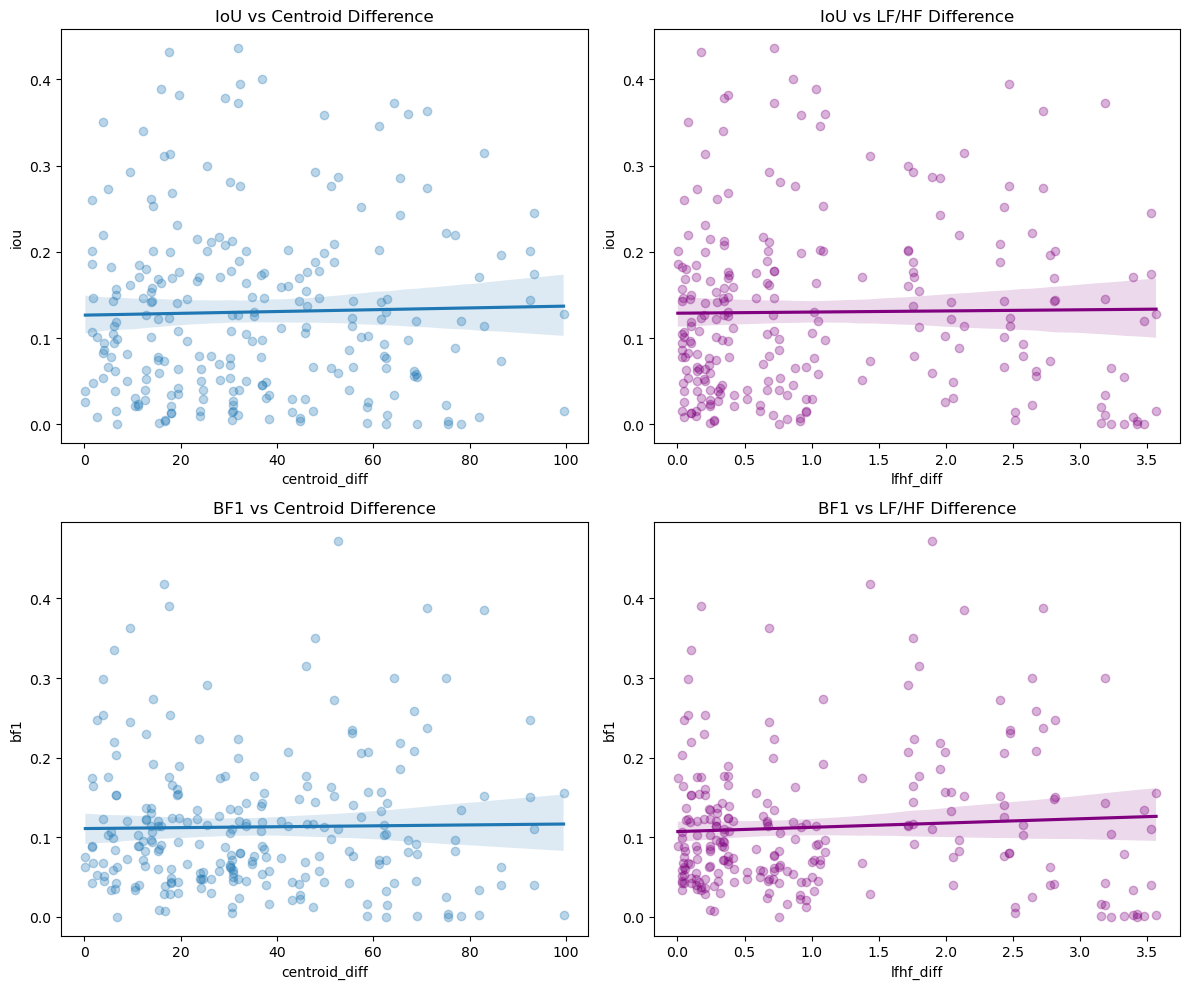

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))

sns.regplot(data=merged, x="centroid_diff", y="iou", scatter_kws={"alpha":0.3}, ax=axes[0,0])
axes[0,0].set_title("IoU vs Centroid Difference")

sns.regplot(data=merged, x="lfhf_diff", y="iou", scatter_kws={"alpha":0.3}, color="purple", ax=axes[0,1])
axes[0,1].set_title("IoU vs LF/HF Difference")

sns.regplot(data=merged, x="centroid_diff", y="bf1", scatter_kws={"alpha":0.3}, ax=axes[1,0])
axes[1,0].set_title("BF1 vs Centroid Difference")

sns.regplot(data=merged, x="lfhf_diff", y="bf1", scatter_kws={"alpha":0.3}, color="purple", ax=axes[1,1])
axes[1,1].set_title("BF1 vs LF/HF Difference")

plt.tight_layout()
plt.show()


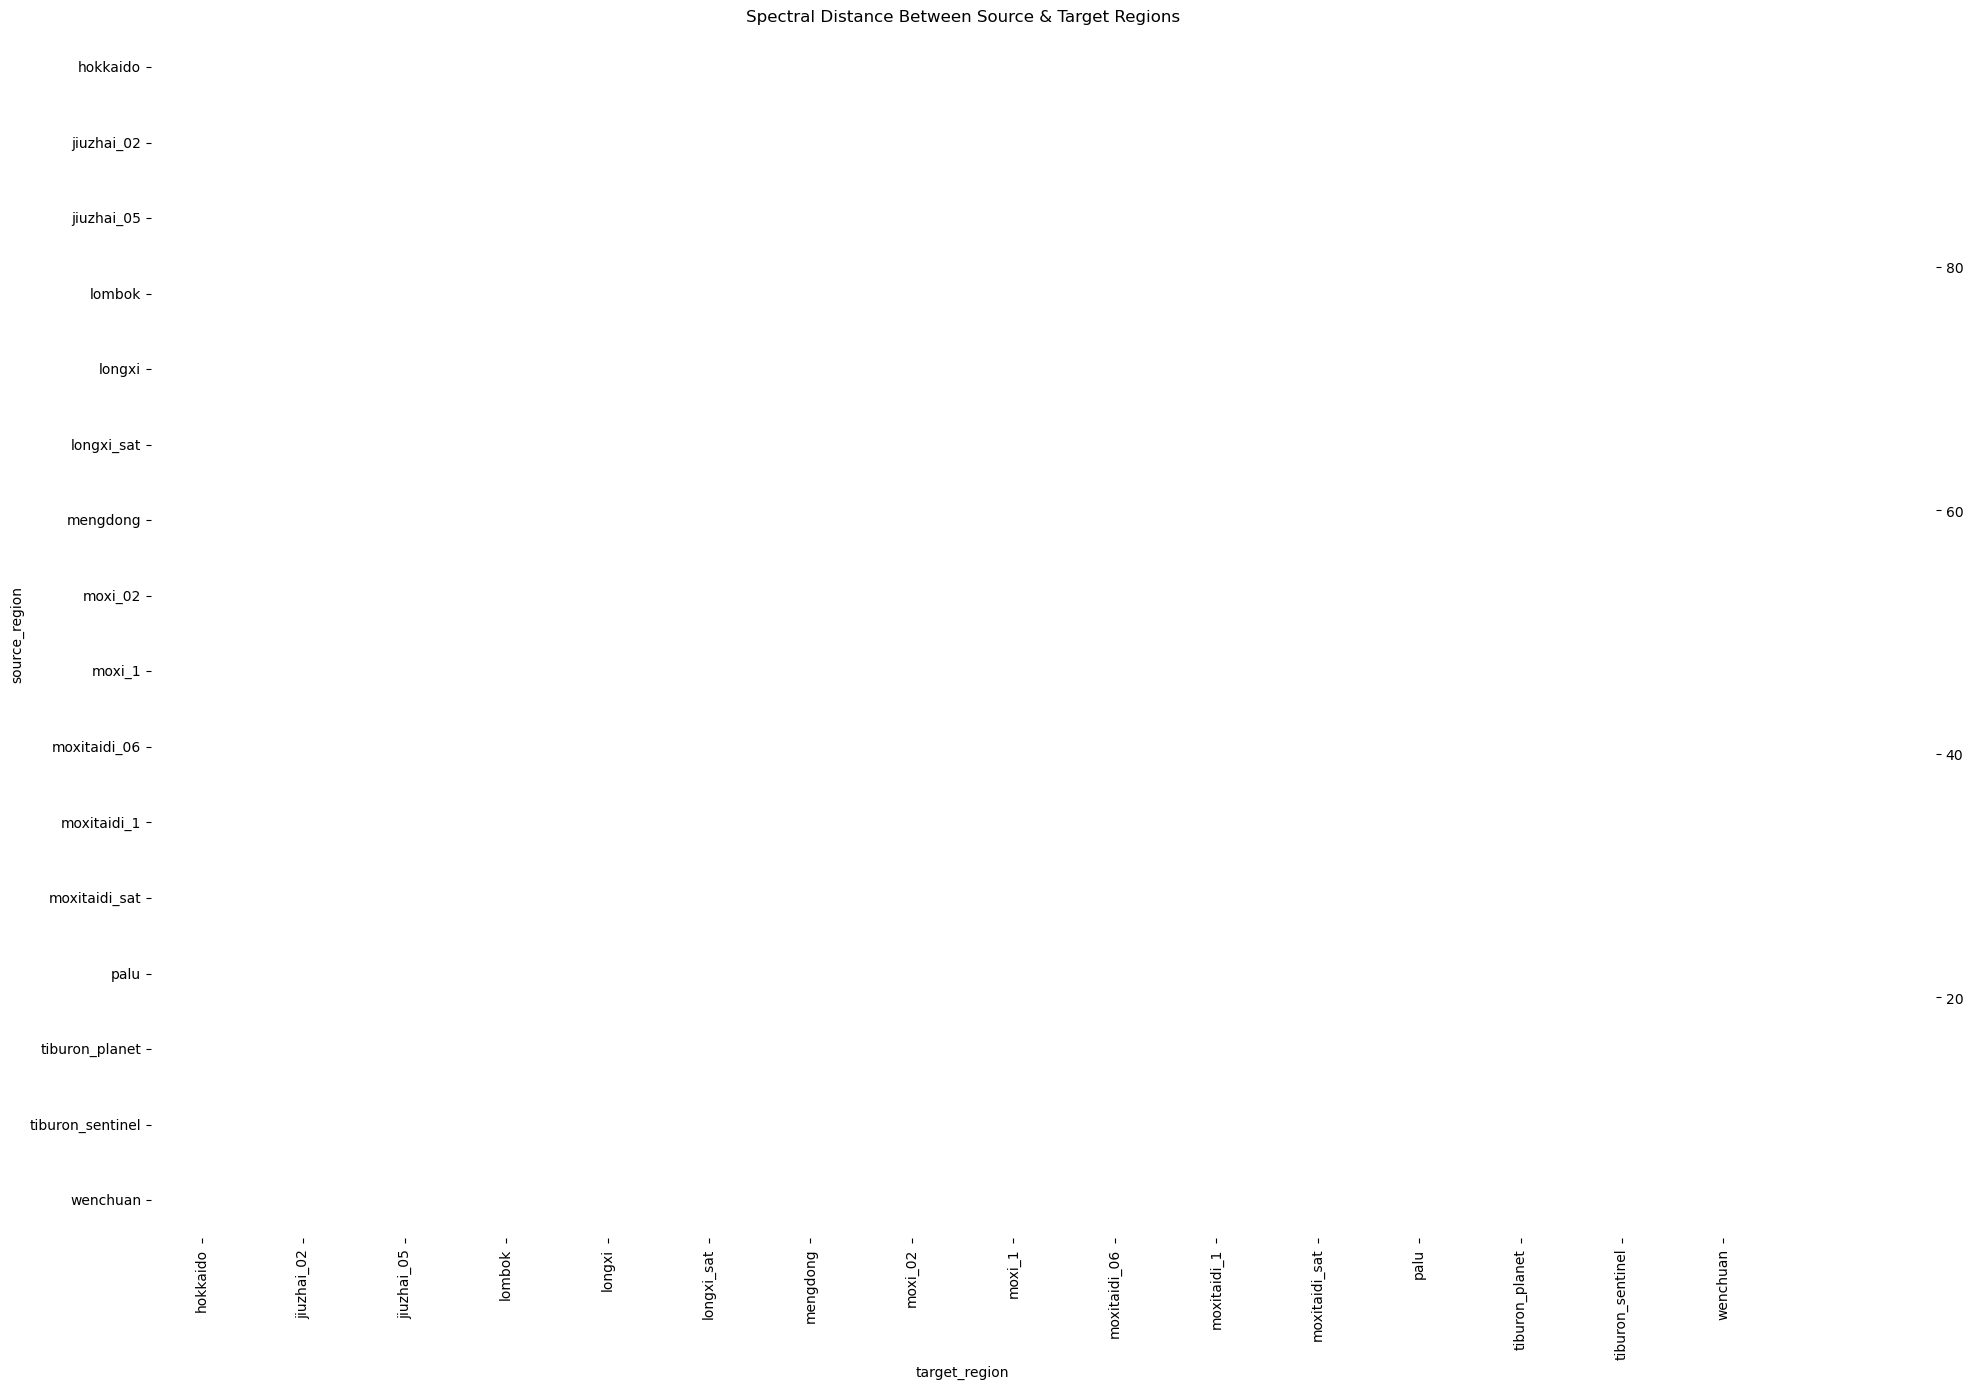

In [25]:
compat = merged.pivot_table(
    index="source_region",
    columns="target_region",
    values="centroid_diff"  # or "lfhf_diff"
)

plt.figure(figsize=(22,14))
sns.heatmap(compat, cmap="coolwarm", center=compat.values.mean())
plt.title("Spectral Distance Between Source & Target Regions")
plt.tight_layout()
plt.show()
